# Baseline signal: liquidation clusters + L1 microstructure

Цель ноутбука - сделать первый рабочий baseline для классификации Binance trades:

- `0`: оставить сделку;
- `1`: отфильтровать сделку как потенциально токсичную для maker.

Это не финальная модель. Это каркас, который уже считает markout/PnL, строит простые liquidation + BBO features, подбирает thresholds на train и проверяет validation.

По умолчанию notebook запускается в быстром sampled режиме на representative days из текущих 3 месяцев. Для полного запуска на всех 90 днях надо переключить `RUN_FULL_3M = True` и `SAMPLE_MOD = None`.

## Что здесь считаем

Для каждой сделки:

- maker side задается через `trade.side`:
  - `buy`: тейкер купил, maker продал;
  - `sell`: тейкер продал, maker купил.
- PnL считается на горизонтах `30s`, `120s`, `300s` по формуле из задания.
- Liquidation side читается как pressure side:
  - `buy` liquidation = forced buy, short liquidation, upward pressure;
  - `sell` liquidation = forced sell, long liquidation, downward pressure.
- Bybit liquidation timestamp сдвигается на `+200ms` перед построением фичей.

In [1]:
from pathlib import Path
from datetime import datetime, timezone, timedelta
import math
import warnings

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.6g}')

DATA = Path('data')
DAY_US = 86_400 * 1_000_000
HORIZONS = [30, 120, 300]
WINDOWS = [1, 5, 30, 120]
SYMBOLS = ['btc', 'eth']

# Fast executed mode. Flip these for the full 3-month run.
RUN_FULL_3M = False
SAMPLE_MOD = 1_000  # None = no sampling. With sampling, turnover is scaled by SAMPLE_MOD for rough constraint checks.

REPRESENTATIVE_TRAIN_DAYS = [
    '2025-12-01', '2025-12-14', '2026-01-13', '2026-01-20', '2026-01-31'
]
REPRESENTATIVE_VAL_DAYS = [
    '2026-02-05', '2026-02-06', '2026-02-21', '2026-02-26'
]

TRAIN_START = '2025-12-01'
TRAIN_END_EXCL = '2026-02-01'
VAL_START = '2026-02-01'
VAL_END_EXCL = '2026-03-01'

def dt_us(day: str) -> int:
    return int(datetime.fromisoformat(day).replace(tzinfo=timezone.utc).timestamp() * 1_000_000)

def days_between(start: str, end_excl: str):
    start_dt = datetime.fromisoformat(start).replace(tzinfo=timezone.utc)
    end_dt = datetime.fromisoformat(end_excl).replace(tzinfo=timezone.utc)
    out = []
    cur = start_dt
    while cur < end_dt:
        out.append(cur.date().isoformat())
        cur += timedelta(days=1)
    return out

if RUN_FULL_3M:
    TRAIN_DAYS = days_between(TRAIN_START, TRAIN_END_EXCL)
    VAL_DAYS = days_between(VAL_START, VAL_END_EXCL)
    SAMPLE_MOD = None
else:
    TRAIN_DAYS = REPRESENTATIVE_TRAIN_DAYS
    VAL_DAYS = REPRESENTATIVE_VAL_DAYS

SAMPLE_SCALE = 1 if SAMPLE_MOD is None else SAMPLE_MOD
print('RUN_FULL_3M:', RUN_FULL_3M)
print('SAMPLE_MOD:', SAMPLE_MOD)
print('train days:', TRAIN_DAYS)
print('validation days:', VAL_DAYS)

RUN_FULL_3M: False
SAMPLE_MOD: 1000
train days: ['2025-12-01', '2025-12-14', '2026-01-13', '2026-01-20', '2026-01-31']
validation days: ['2026-02-05', '2026-02-06', '2026-02-21', '2026-02-26']


In [2]:
def data_path(kind: str, symbol: str) -> Path:
    if kind == 'trades':
        return DATA / 'binance_trades' / f'perp_{symbol}usdt.parquet'
    if kind == 'bbo':
        return DATA / 'binance_booktickers' / f'perp_{symbol}usdt.parquet'
    if kind == 'bin_liq':
        return DATA / 'binance_liquidations' / f'perp_{symbol}usdt.parquet'
    if kind == 'bybit_liq':
        return DATA / 'bybit_liquidations' / f'{symbol}usdt.parquet'
    raise ValueError(kind)

def load_bbo_window(symbol: str, start_us: int, end_us: int) -> pl.DataFrame:
    margin_us = 310 * 1_000_000
    return (
        pl.scan_parquet(data_path('bbo', symbol))
        .filter((pl.col('timestamp') >= start_us - margin_us) & (pl.col('timestamp') <= end_us + margin_us))
        .select([
            pl.col('timestamp').alias('bbo_ts'),
            pl.col('bid_price'),
            pl.col('ask_price'),
            pl.col('bid_amount'),
            pl.col('ask_amount'),
            ((pl.col('bid_price') + pl.col('ask_price')) / 2).alias('mid'),
            ((pl.col('ask_price') - pl.col('bid_price')) / ((pl.col('ask_price') + pl.col('bid_price')) / 2) * 10_000).alias('spread_bps'),
            ((pl.col('bid_amount') - pl.col('ask_amount')) / (pl.col('bid_amount') + pl.col('ask_amount'))).alias('imbalance'),
            ((pl.col('ask_price') * pl.col('bid_amount') + pl.col('bid_price') * pl.col('ask_amount')) / (pl.col('bid_amount') + pl.col('ask_amount'))).alias('microprice'),
        ])
        .collect()
        .sort('bbo_ts')
        .with_columns(((pl.col('microprice') - pl.col('mid')) / pl.col('mid') * 10_000).alias('microprice_minus_mid_bps'))
    )

def load_liq_second_features(symbol: str, start_us: int, end_us: int) -> pl.DataFrame:
    # Need history for 120s rolling windows.
    start_hist = start_us - 130 * 1_000_000
    end_hist = end_us + 1_000_000
    source_frames = []
    for source, kind, delay_us in [('bin', 'bin_liq', 0), ('byb', 'bybit_liq', 200_000)]:
        cols = [
            f'{source}_buy_notional', f'{source}_sell_notional',
            f'{source}_buy_count', f'{source}_sell_count',
        ]
        frame = (
            pl.scan_parquet(data_path(kind, symbol))
            .filter((pl.col('timestamp') + delay_us >= start_hist) & (pl.col('timestamp') + delay_us <= end_hist))
            .with_columns([
                ((pl.col('timestamp') + delay_us) // 1_000_000).cast(pl.Int64).alias('sec'),
                (pl.col('price') * pl.col('amount')).alias('notional'),
            ])
            .group_by(['sec', 'side'])
            .agg([pl.len().alias('count'), pl.sum('notional').alias('notional')])
            .with_columns([
                pl.when(pl.col('side') == 'buy').then(pl.col('notional')).otherwise(0).alias(cols[0]),
                pl.when(pl.col('side') == 'sell').then(pl.col('notional')).otherwise(0).alias(cols[1]),
                pl.when(pl.col('side') == 'buy').then(pl.col('count')).otherwise(0).alias(cols[2]),
                pl.when(pl.col('side') == 'sell').then(pl.col('count')).otherwise(0).alias(cols[3]),
            ])
            .group_by('sec')
            .agg([pl.sum(c).alias(c) for c in cols])
            .collect()
        )
        source_frames.append(frame)

    sec_start = start_hist // 1_000_000
    sec_end = end_hist // 1_000_000
    out = pl.DataFrame({'sec': pl.arange(sec_start, sec_end + 1, eager=True)})
    for frame in source_frames:
        out = out.join(frame, on='sec', how='left')
    out = out.fill_null(0).sort('sec')

    base_cols = [c for c in out.columns if c != 'sec']
    for w in WINDOWS:
        out = out.with_columns([
            pl.col(c).rolling_sum(window_size=w, min_samples=1).alias(f'{c}_{w}s')
            for c in base_cols
        ])
        out = out.with_columns([
            (pl.col(f'bin_buy_notional_{w}s') + pl.col(f'byb_buy_notional_{w}s')).alias(f'all_buy_liq_notional_{w}s'),
            (pl.col(f'bin_sell_notional_{w}s') + pl.col(f'byb_sell_notional_{w}s')).alias(f'all_sell_liq_notional_{w}s'),
            (pl.col(f'bin_buy_count_{w}s') + pl.col(f'byb_buy_count_{w}s')).alias(f'all_buy_liq_count_{w}s'),
            (pl.col(f'bin_sell_count_{w}s') + pl.col(f'byb_sell_count_{w}s')).alias(f'all_sell_liq_count_{w}s'),
        ])

    keep = ['sec'] + [c for c in out.columns if c.startswith(('all_', 'bin_', 'byb_'))]
    return out.select(keep)

In [3]:
def load_trade_day(symbol: str, day: str, sample_mod: int | None = SAMPLE_MOD) -> pl.DataFrame:
    start_us = dt_us(day)
    end_us = start_us + DAY_US
    lf = (
        pl.scan_parquet(data_path('trades', symbol))
        .filter((pl.col('timestamp') >= start_us) & (pl.col('timestamp') < end_us))
        .select(['timestamp', 'side', 'price', 'amount'])
    )
    if sample_mod is not None:
        lf = (
            lf.with_columns(pl.struct(['timestamp', 'side', 'price', 'amount']).hash(seed=42).alias('_hash'))
            .filter((pl.col('_hash') % sample_mod) == 0)
            .drop('_hash')
        )
    return lf.collect().sort('timestamp')

def build_trade_features_for_day(symbol: str, day: str, sample_mod: int | None = SAMPLE_MOD) -> pl.DataFrame:
    start_us = dt_us(day)
    end_us = start_us + DAY_US
    trades = load_trade_day(symbol, day, sample_mod=sample_mod)
    if trades.height == 0:
        return trades

    bbo = load_bbo_window(symbol, start_us, end_us)
    liq = load_liq_second_features(symbol, start_us, end_us)

    df = (
        trades
        .with_columns([
            pl.lit(symbol).alias('symbol'),
            pl.lit(day).alias('day'),
            (pl.col('price') * pl.col('amount')).alias('notional'),
            pl.min_horizontal(pl.col('price') * pl.col('amount'), pl.lit(100_000.0)).alias('w'),
            (pl.col('timestamp') // 1_000_000).cast(pl.Int64).alias('sec'),
            pl.when(pl.col('side') == 'buy').then(1.0).otherwise(-1.0).alias('s'),
        ])
        .join_asof(bbo, left_on='timestamp', right_on='bbo_ts', strategy='backward')
        .with_columns([
            ((pl.col('timestamp') - pl.col('bbo_ts')) / 1_000).alias('bbo_lag_ms'),
            ((pl.col('microprice') - pl.col('mid')) / pl.col('mid') * 10_000).alias('microprice_minus_mid_bps'),
        ])
    )

    # Past mid returns for continuation/reversal context.
    for past_s in [1, 5, 30]:
        df = df.with_columns((pl.col('timestamp') - past_s * 1_000_000).alias(f'target_past_{past_s}s'))
        past_mid = bbo.select([
            pl.col('bbo_ts').alias(f'bbo_past_ts_{past_s}s'),
            pl.col('mid').alias(f'mid_past_{past_s}s'),
        ])
        df = df.join_asof(past_mid, left_on=f'target_past_{past_s}s', right_on=f'bbo_past_ts_{past_s}s', strategy='backward')
        df = df.with_columns(
            ((pl.col('mid') - pl.col(f'mid_past_{past_s}s')) / pl.col(f'mid_past_{past_s}s') * 10_000 * pl.col('s')).alias(f'side_adj_ret_{past_s}s_bps')
        )

    # Future markouts / labels.
    for h in HORIZONS:
        df = df.with_columns((pl.col('timestamp') + h * 1_000_000).alias(f'target_{h}s'))
        future_mid = bbo.select([
            pl.col('bbo_ts').alias(f'bbo_future_ts_{h}s'),
            pl.col('mid').alias(f'mid_{h}s'),
        ])
        df = df.join_asof(future_mid, left_on=f'target_{h}s', right_on=f'bbo_future_ts_{h}s', strategy='backward')
        df = df.with_columns([
            ((pl.col(f'target_{h}s') - pl.col(f'bbo_future_ts_{h}s')) / 1_000).alias(f'bbo_future_lag_{h}s_ms'),
            (-pl.col('s') * (pl.col(f'mid_{h}s') - pl.col('price')) / pl.col('price') * 10_000 + 0.5).alias(f'pnl_{h}s_bps'),
        ])

    df = df.join(liq, on='sec', how='left').fill_null(0)

    # Side-adjusted liquidation features: positive means pressure in the same direction as taker trade.
    exprs = [
        (pl.col('imbalance') * pl.col('s')).alias('side_adj_imbalance'),
        (pl.col('microprice_minus_mid_bps') * pl.col('s')).alias('side_adj_microprice_bps'),
        (pl.col('bbo_lag_ms') > 250).cast(pl.Int8).alias('stale_bbo_flag'),
    ]
    for w in WINDOWS:
        buy = pl.col(f'all_buy_liq_notional_{w}s')
        sell = pl.col(f'all_sell_liq_notional_{w}s')
        exprs.extend([
            pl.when(pl.col('side') == 'buy').then(buy).otherwise(sell).alias(f'same_liq_notional_{w}s'),
            pl.when(pl.col('side') == 'buy').then(sell).otherwise(buy).alias(f'opp_liq_notional_{w}s'),
            ((buy - sell) / (buy + sell + 1.0) * pl.col('s')).alias(f'side_adj_liq_imbalance_{w}s'),
            (buy + sell).alias(f'total_liq_notional_{w}s'),
        ])
    return df.with_columns(exprs)

In [4]:
def build_dataset(days, symbols=SYMBOLS, sample_mod: int | None = SAMPLE_MOD) -> pl.DataFrame:
    parts = []
    for day in days:
        for symbol in symbols:
            print(f'building {symbol} {day} ...')
            part = build_trade_features_for_day(symbol, day, sample_mod=sample_mod)
            print('  rows:', part.height)
            parts.append(part)
    return pl.concat(parts, how='diagonal_relaxed') if parts else pl.DataFrame()

train_df = build_dataset(TRAIN_DAYS)
val_df = build_dataset(VAL_DAYS)

print('train rows:', train_df.height)
print('validation rows:', val_df.height)
print('columns:', len(train_df.columns))
train_df.select(['symbol', 'day', 'side', 'price', 'same_liq_notional_5s', 'spread_bps', 'side_adj_ret_1s_bps', 'pnl_30s_bps']).head()

building btc 2025-12-01 ...


  rows: 6631
building eth 2025-12-01 ...


  rows: 10700
building btc 2025-12-14 ...
  rows: 2411
building eth 2025-12-14 ...


  rows: 4409
building btc 2026-01-13 ...
  rows: 4227
building eth 2026-01-13 ...


  rows: 6582
building btc 2026-01-20 ...
  rows: 4687
building eth 2026-01-20 ...


...

  rows: 16244
building eth 2026-02-06 ...


  rows: 24317
building btc 2026-02-21 ...
  rows: 1970
building eth 2026-02-21 ...


  rows: 2581
building btc 2026-02-26 ...
  rows: 5269
building eth 2026-02-26 ...


  rows: 8537
train rows: 70551
validation rows: 109217
columns: 123


symbol,day,side,price,same_liq_notional_5s,spread_bps,side_adj_ret_1s_bps,pnl_30s_bps
str,str,str,f64,f64,f64,f64,f64
"""btc""","""2025-12-01""","""buy""",90280.1,0.0,0.011077,-0.886053,-4.268493
"""btc""","""2025-12-01""","""sell""",90282.8,44280.189,0.011076,1.893689,5.556334
"""btc""","""2025-12-01""","""buy""",90293.2,0.0,0.011076,-1.893689,-4.478226
"""btc""","""2025-12-01""","""sell""",90261.6,0.0,0.033236,1.451103,9.966927
"""btc""","""2025-12-01""","""sell""",90263.5,0.0,0.011079,1.783417,10.077515


In [5]:
FEATURE_COLS = []
for w in WINDOWS:
    FEATURE_COLS += [
        f'same_liq_notional_{w}s', f'opp_liq_notional_{w}s',
        f'total_liq_notional_{w}s', f'side_adj_liq_imbalance_{w}s',
        f'byb_buy_count_{w}s', f'byb_sell_count_{w}s',
        f'bin_buy_notional_{w}s', f'bin_sell_notional_{w}s',
    ]
FEATURE_COLS += [
    'spread_bps', 'imbalance', 'side_adj_imbalance',
    'microprice_minus_mid_bps', 'side_adj_microprice_bps',
    'side_adj_ret_1s_bps', 'side_adj_ret_5s_bps', 'side_adj_ret_30s_bps',
    'bbo_lag_ms', 'stale_bbo_flag', 'notional',
]

LOG_FEATURES = [c for c in FEATURE_COLS if 'notional' in c or c.endswith('_count_1s') or c.endswith('_count_5s') or c.endswith('_count_30s') or c.endswith('_count_120s')]

def to_model_frame(df: pl.DataFrame, horizon: int) -> pd.DataFrame:
    cols = ['symbol', 'day', 'side', 'timestamp', 'w', f'pnl_{horizon}s_bps'] + FEATURE_COLS
    pdf = df.select([c for c in cols if c in df.columns]).to_pandas()
    pdf = pdf.replace([np.inf, -np.inf], np.nan)
    for c in FEATURE_COLS:
        if c not in pdf.columns:
            continue
        pdf[c] = pdf[c].fillna(0.0)
        if c in LOG_FEATURES:
            pdf[c] = np.log1p(np.clip(pdf[c], 0, None))
    pdf[f'bad_{horizon}s'] = (pdf[f'pnl_{horizon}s_bps'] < 0).astype(int)
    return pdf

def weighted_mean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    ok = np.isfinite(x) & np.isfinite(w) & (w > 0)
    if ok.sum() == 0:
        return np.nan
    return float(np.sum(x[ok] * w[ok]) / np.sum(w[ok]))

def metrics_for_filter(pdf: pd.DataFrame, horizon: int, filter_values, sample_scale=SAMPLE_SCALE):
    pnl_col = f'pnl_{horizon}s_bps'
    f = np.asarray(filter_values).astype(bool)
    w = pdf['w'].to_numpy(dtype=float)
    pnl = pdf[pnl_col].to_numpy(dtype=float)
    days = max(1, pdf['day'].nunique())
    all_pnl = weighted_mean(pnl, w)
    kept_pnl = weighted_mean(pnl[~f], w[~f])
    filtered_pnl = weighted_mean(pnl[f], w[f])
    kept_turnover_per_day = float(w[~f].sum() * sample_scale / days)
    filtered_turnover_per_day = float(w[f].sum() * sample_scale / days)
    return {
        'horizon_s': horizon,
        'rows': len(pdf),
        'filtered_rows_share': float(f.mean()),
        'PnL_all': all_pnl,
        'PnL_kept': kept_pnl,
        'PnL_filtered': filtered_pnl,
        'Score': kept_pnl - all_pnl,
        'KeptTurnoverPerDay': kept_turnover_per_day,
        'FilteredTurnoverPerDay': filtered_turnover_per_day,
        'turnover_constraint_ok': kept_turnover_per_day >= 500_000,
    }

## Rule baseline

Простое правило для sanity-check:

- фильтруем сделки, если они идут в сторону недавнего liquidation pressure;
- и одновременно есть недавний side-adjusted price move или широкий spread.

Пороги подбираются по train quantiles. Это intentionally simple baseline, не финальный сигнал.

In [6]:
def fit_rule_params(train_pl: pl.DataFrame):
    return {
        'same_liq_5s_thr': float(train_pl.select(pl.col('same_liq_notional_5s').quantile(0.90)).item()),
        'same_liq_30s_thr': float(train_pl.select(pl.col('same_liq_notional_30s').quantile(0.90)).item()),
        'spread_thr': float(train_pl.select(pl.col('spread_bps').quantile(0.995)).item()),
        'ret_1s_thr': 0.5,
        'ret_5s_thr': 1.0,
    }

def apply_rule_filter(df: pl.DataFrame, params) -> np.ndarray:
    filt = (
        ((pl.col('same_liq_notional_5s') > params['same_liq_5s_thr']) & (pl.col('side_adj_ret_1s_bps') > params['ret_1s_thr'])) |
        ((pl.col('same_liq_notional_30s') > params['same_liq_30s_thr']) & (pl.col('side_adj_ret_5s_bps') > params['ret_5s_thr'])) |
        ((pl.col('spread_bps') > params['spread_thr']) & (pl.col('side_adj_ret_1s_bps') > 0))
    )
    return df.select(filt.alias('filter')).to_series().to_numpy().astype(bool)

rule_params = fit_rule_params(train_df)
rule_params

{'same_liq_5s_thr': 3867.457799999301,
 'same_liq_30s_thr': 87989.21370000001,
 'spread_thr': 3.2487795703070876,
 'ret_1s_thr': 0.5,
 'ret_5s_thr': 1.0}

In [7]:
rule_rows = []
for h in HORIZONS:
    train_pdf = to_model_frame(train_df, h)
    val_pdf = to_model_frame(val_df, h)
    train_filter = apply_rule_filter(train_df, rule_params)
    val_filter = apply_rule_filter(val_df, rule_params)
    rule_rows.append({'split': 'train', 'model': 'rule'} | metrics_for_filter(train_pdf, h, train_filter))
    rule_rows.append({'split': 'validation', 'model': 'rule'} | metrics_for_filter(val_pdf, h, val_filter))

rule_metrics = pd.DataFrame(rule_rows)
rule_metrics

,split,model,horizon_s,rows,filtered_rows_share,PnL_all,PnL_kept,PnL_filtered,Score,KeptTurnoverPerDay,FilteredTurnoverPerDay,turnover_constraint_ok
0,train,rule,30,70551,0.0888435,-0.220996,-0.181767,-0.495766,0.0392289,2.7986e+10,3.99557e+09,True
1,validation,rule,30,109217,0.0813426,-0.382983,-0.73638,2.04369,-0.353397,3.53349e+10,5.14583e+09,True
2,train,rule,120,70551,0.0888435,1.67557,0.331732,11.0882,-1.34384,2.7986e+10,3.99557e+09,True
3,validation,rule,120,109217,0.0813426,-0.113975,-0.885178,5.18165,-0.771203,3.53349e+10,5.14583e+09,True
4,train,rule,300,70551,0.0888435,0.75486,-0.345548,8.46242,-1.10041,2.7986e+10,3.99557e+09,True
5,validation,rule,300,109217,0.0813426,-0.216274,-0.996265,5.13969,-0.77999,3.53349e+10,5.14583e+09,True


## ML baseline

Две очень простые постановки:

1. `LogisticRegression`: предсказываем вероятность `pnl < 0`.
2. `Ridge`: предсказываем сам maker PnL; фильтруем низкий predicted PnL.

Threshold выбирается на train по максимальному `Score` при turnover constraint. Потом тот же threshold применяется на validation.

In [8]:
def choose_threshold_by_score(pdf: pd.DataFrame, horizon: int, score_values, min_turnover_per_day=500_000):
    candidates = np.quantile(score_values, np.linspace(0.50, 0.995, 80))
    best = None
    for thr in candidates:
        filt = score_values >= thr
        m = metrics_for_filter(pdf, horizon, filt)
        if not m['turnover_constraint_ok']:
            continue
        row = {'threshold': float(thr)} | m
        if best is None or row['Score'] > best['Score']:
            best = row
    return best

def fit_ml_for_horizon(train_pdf: pd.DataFrame, val_pdf: pd.DataFrame, horizon: int):
    X_train = train_pdf[FEATURE_COLS].to_numpy(dtype=float)
    X_val = val_pdf[FEATURE_COLS].to_numpy(dtype=float)
    y_train_bad = train_pdf[f'bad_{horizon}s'].to_numpy(dtype=int)
    y_val_bad = val_pdf[f'bad_{horizon}s'].to_numpy(dtype=int)
    y_train_pnl = train_pdf[f'pnl_{horizon}s_bps'].to_numpy(dtype=float)

    logit = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=500, class_weight='balanced', C=0.25)
    )
    logit.fit(X_train, y_train_bad)
    train_bad_prob = logit.predict_proba(X_train)[:, 1]
    val_bad_prob = logit.predict_proba(X_val)[:, 1]
    logit_thr = choose_threshold_by_score(train_pdf, horizon, train_bad_prob)

    ridge = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
    ridge.fit(X_train, y_train_pnl)
    train_pred_pnl = ridge.predict(X_train)
    val_pred_pnl = ridge.predict(X_val)
    # For ridge, high toxicity score = low predicted pnl.
    ridge_train_toxicity = -train_pred_pnl
    ridge_val_toxicity = -val_pred_pnl
    ridge_thr = choose_threshold_by_score(train_pdf, horizon, ridge_train_toxicity)

    rows = []
    if logit_thr is not None:
        rows.append({'split': 'train', 'model': 'logit_bad_prob', 'auc_bad': roc_auc_score(y_train_bad, train_bad_prob), 'threshold': logit_thr['threshold']} | metrics_for_filter(train_pdf, horizon, train_bad_prob >= logit_thr['threshold']))
        rows.append({'split': 'validation', 'model': 'logit_bad_prob', 'auc_bad': roc_auc_score(y_val_bad, val_bad_prob), 'threshold': logit_thr['threshold']} | metrics_for_filter(val_pdf, horizon, val_bad_prob >= logit_thr['threshold']))
    if ridge_thr is not None:
        rows.append({'split': 'train', 'model': 'ridge_pred_pnl', 'auc_bad': roc_auc_score(y_train_bad, ridge_train_toxicity), 'threshold': ridge_thr['threshold']} | metrics_for_filter(train_pdf, horizon, ridge_train_toxicity >= ridge_thr['threshold']))
        rows.append({'split': 'validation', 'model': 'ridge_pred_pnl', 'auc_bad': roc_auc_score(y_val_bad, ridge_val_toxicity), 'threshold': ridge_thr['threshold']} | metrics_for_filter(val_pdf, horizon, ridge_val_toxicity >= ridge_thr['threshold']))
    return pd.DataFrame(rows)

ml_parts = []
for h in HORIZONS:
    train_pdf = to_model_frame(train_df, h)
    val_pdf = to_model_frame(val_df, h)
    ml_parts.append(fit_ml_for_horizon(train_pdf, val_pdf, h))

ml_metrics = pd.concat(ml_parts, ignore_index=True)
all_metrics = pd.concat([rule_metrics, ml_metrics], ignore_index=True)
all_metrics.sort_values(['horizon_s', 'split', 'Score'], ascending=[True, True, False])

,split,model,horizon_s,rows,filtered_rows_share,PnL_all,PnL_kept,PnL_filtered,Score,KeptTurnoverPerDay,FilteredTurnoverPerDay,turnover_constraint_ok,auc_bad,threshold
6,train,logit_bad_prob,30,70551,0.374679,-0.220996,-0.0558041,-0.602165,0.165192,2.2312e+10,9.66963e+09,True,0.549985,0.515611
8,train,ridge_pred_pnl,30,70551,0.0112826,-0.220996,-0.0851973,-10.9333,0.135799,3.15813e+10,4.00354e+08,True,0.519059,4.25643
0,train,rule,30,70551,0.0888435,-0.220996,-0.181767,-0.495766,0.0392289,2.7986e+10,3.99557e+09,True,NaN,NaN
7,validation,logit_bad_prob,30,109217,0.390736,-0.382983,0.100857,-1.4198,0.48384,2.76006e+10,1.28801e+10,True,0.516924,0.515611
9,validation,ridge_pred_pnl,30,109217,0.0186052,-0.382983,-0.487434,4.83404,-0.10445,3.96861e+10,7.9456e+08,True,0.500958,4.25643
1,validation,rule,30,109217,0.0813426,-0.382983,-0.73638,2.04369,-0.353397,3.53349e+10,5.14583e+09,True,NaN,NaN
10,train,logit_bad_prob,120,70551,0.493728,1.67557,3.61474,-0.553155,1.93917,1.71017e+10,1.48799e+10,True,0.551997,0.505232
12,train,ridge_pred_pnl,120,70551,0.500021,1.67557,2.4917,0.487613,0.81613,1.89576e+10,1.3024e+10,True,0.528724,0.325863
2,train,rule,120,70551,0.0888435,1.67557,0.331732,11.0882,-1.34384,2.7986e+10,3.99557e+09,True,NaN,NaN
13,validation,ridge_pred_pnl,120,109217,0.501717,-0.113975,1.15854,-1.86242,1.27251,2.34291e+10,1.70516e+10,True,0.515014,0.325863


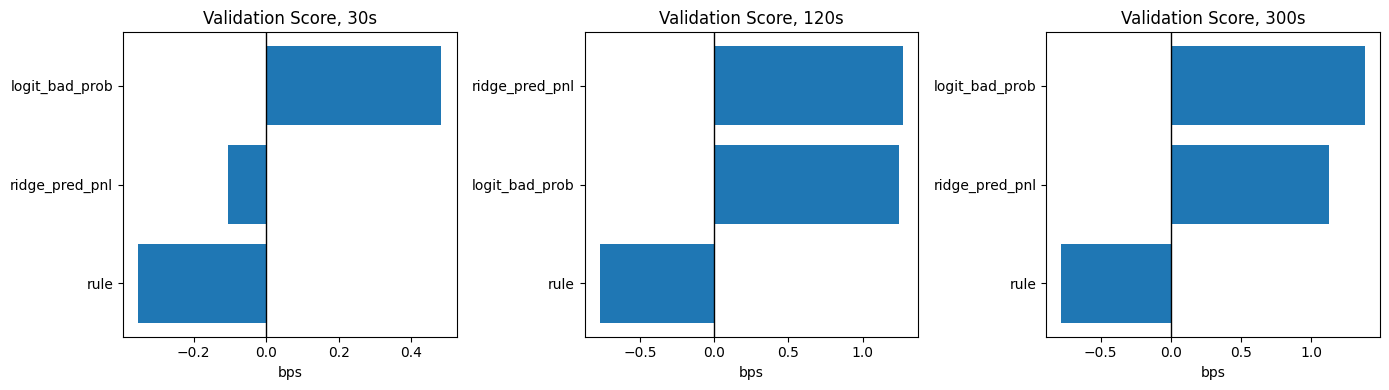

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, h in zip(axes, HORIZONS):
    tmp = all_metrics[(all_metrics['split'] == 'validation') & (all_metrics['horizon_s'] == h)].copy()
    tmp = tmp.sort_values('Score')
    ax.barh(tmp['model'], tmp['Score'])
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'Validation Score, {h}s')
    ax.set_xlabel('bps')
plt.tight_layout()
plt.show()

## Simple signal function skeleton

На hidden test от нас потребуется функция, которая принимает четыре фрейма и возвращает `0/1` по trades. Ниже не финальная submission-функция, а skeleton: текущий baseline пока строит features day-by-day из parquet, но логика фильтра такая же.

Для финальной версии надо будет адаптировать `build_trade_features_for_day` так, чтобы она принимала input frames вместо путей к parquet.

In [10]:
def rule_signal_from_feature_frame(features: pl.DataFrame, params=rule_params) -> np.ndarray:
    """Return 1 for filtered trades, 0 for kept trades."""
    return apply_rule_filter(features, params).astype(np.int8)

# Example on validation feature frame.
example_signal = rule_signal_from_feature_frame(val_df)
print('signal length:', len(example_signal))
print('filtered share:', example_signal.mean())

signal length: 109217
filtered share: 0.08134264812254502


## Notes / next improvements

- Current executed results are sampled. With `RUN_FULL_3M=True`, the same code processes all current 3 months day-by-day.
- Need add more robust train/validation threshold search on full data.
- Need add stale BBO handling explicitly in scoring: exclude or penalize trades whose future BBO markout is stale because of multi-minute BBO gaps.
- Need separate parameters by symbol; current rule thresholds are global across BTC/ETH.
- Need compare four ablations: liquidation-only, BBO-only, trade-flow-only, combined.
- Need final submission wrapper that accepts four frames instead of reading parquet paths.